# Caderno 8 - Comparação de ranking de sistemas de busca gerado por diversos qrels

## 1. Parâmetros

In [1]:
PASTA_DOCS_QRELS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/'
PASTA_QRELS_LEAVE_ONE_OUT = f'{PASTA_DOCS_QRELS}qrels possiveis/'
PASTA_QRELS_LLMS = './dados/outputs/4 - qrel llm/'
PASTA_RUNS = './dados/outputs/7 - runs/'

ARQUIVO_QRELS = f'{PASTA_DOCS_QRELS}qrel.csv'
ARQUIVO_RAW_HUMAN_EVAL = f'{PASTA_DOCS_QRELS}raw_human_eval.csv'

In [2]:
MAPA_NOME_RUNS = {
    'run_bm25_0.9_0.4_assunto_e_texto': 'S_1',
    'run_bm25_0.9_0.4_texto': 'S_2',
    'run_bm25_0.82_0.68_assunto_e_texto': 'S_3',
    'run_bm25_0.82_0.68_texto': 'S_4',
    'run_bm25_1_0.3_assunto_e_texto': 'S_5',
    'run_bm25_1_0.3_texto': 'S_6',
    'run_bm25_1_0.9_assunto_e_texto': 'S_7',
    'run_bm25_1_0.9_texto': 'S_8',
    'run_text-embedding-3-large': 'S_9',
    'run_text-embedding-3-small': 'S_10',
    'run_gemini-embedding-001': 'S_11',
    'run_qwen_4b': 'S_12',
    'run_qwen_8b': 'S_13',
    'run_bm25_1_0.9_texto_text-embedding-3-small': 'S_14',
    'run_bm25_1_0.9_texto_gemini-embedding-001': 'S_15'
}

MAPA_NOME_QRELS = {
    'qrel_deepseek-chat_cot': 'deepseek-3.2_rationale',
    'qrel_deepseek-chat_simple': 'deepseek-3.2_simple',
    'qrel_gpt-5-mini-2025-08-07_cot': 'gpt-5-mini_rationale',
    'qrel_gpt-5-mini-2025-08-07_simple': 'gpt-5-mini_simple',
    'qrel_sabiazinho-4-2026-01-06_cot': 'sabiazinho-4_rationale',
    'qrel_sabiazinho-4-2026-01-06_simple': 'sabiazinho-4_simple'
}

# Guarda a ordem para exibição dos gráficos
NOME_QRELS_REF = "Reference"
CARREGAR_QRELS_LEAVE_ONE_OUT = False
subtitle_order = [
    NOME_QRELS_REF,
    # Para o caso de querer testar com os leave_one_out, descomentar as linhas abaixo e setar CARREGAR_QRELS_LEAVE_ONE_OUT = True
    #"qrels_leave_A_1_out",
    #"qrels_leave_A_2_out",
    #"qrels_leave_A_3_out",
    #"qrels_leave_A_4_out",
    "A_1",
    "A_2",
    "A_3",
    "A_4",
    "deepseek-3.2_simple",
    "deepseek-3.2_rationale",
    "gpt-5-mini_simple",
    "gpt-5-mini_rationale",
    "sabiazinho-4_simple",
    "sabiazinho-4_rationale",
]

## 2. Carrega todos os qrels

In [3]:
# Carrega todos os qrels de LLMs
from pathlib import Path
import pandas as pd

qrels = {}

# Carrega o qrels humano
qrels[NOME_QRELS_REF] = pd.read_csv(ARQUIVO_QRELS)

# Carrega os qrels leave-one-out
if CARREGAR_QRELS_LEAVE_ONE_OUT:
    qrels["qrels_leave_A_1_out"] = pd.read_csv(f'{PASTA_QRELS_LEAVE_ONE_OUT}qrels_leave_A_1_out.csv')
    qrels["qrels_leave_A_2_out"] = pd.read_csv(f'{PASTA_QRELS_LEAVE_ONE_OUT}qrels_leave_A_2_out.csv')
    qrels["qrels_leave_A_3_out"] = pd.read_csv(f'{PASTA_QRELS_LEAVE_ONE_OUT}qrels_leave_A_3_out.csv')
    qrels["qrels_leave_A_4_out"] = pd.read_csv(f'{PASTA_QRELS_LEAVE_ONE_OUT}qrels_leave_A_4_out.csv')

########## CARREGA QRELS LLM ########## 

# Percorre todos os arquivos .csv da pasta
PASTA_QRELS_LLMS = Path(PASTA_QRELS_LLMS)
for arquivo in PASTA_QRELS_LLMS.glob("*.csv"):
    # Nome do arquivo sem extensão
    nome_qrels = arquivo.stem
    
    # Lê o CSV
    df = pd.read_csv(arquivo)
    
    # Salva no dicionário
    qrels[MAPA_NOME_QRELS.get(nome_qrels, nome_qrels)] = df


########## CARREGA QRELS ANOTADORES HUMANOS INDIVIDUAIS ########## 

# Gera os qrels de cada anotador individual
df_raw_human_eval = pd.read_csv(ARQUIVO_RAW_HUMAN_EVAL)
# Renomeia SCORE
df_raw_human_eval = df_raw_human_eval.rename(columns={"AVALIACAO": "SCORE"})
# Agrupa por usuário/query_key/score
df_raw_human_eval = df_raw_human_eval.sort_values(
    by=["USUARIO_AVALIADOR", "QUERY_KEY", "SCORE"],
    ascending=[True, True, False]
)
# Cria RANK (reinicia para cada QUERY_KEY dentro de cada avaliador)
df_raw_human_eval["RANK"] = (
    df_raw_human_eval.groupby(["USUARIO_AVALIADOR", "QUERY_KEY"])
      .cumcount() + 1
)
# Cria um df para cada avaliador
for user, grupo in df_raw_human_eval.groupby("USUARIO_AVALIADOR"):
    qrels[user] = grupo[["QUERY_KEY", "DOC_KEY", "SCORE", "RANK"]].reset_index(drop=True)

print(f"{len(qrels)} arquivos carregados.")

11 arquivos carregados.


## 3. Carrega todos os runs

In [4]:
runs = {}

# Percorre todos os arquivos .csv da pasta
PASTA_RUNS = Path(PASTA_RUNS)
for arquivo in PASTA_RUNS.glob("*.csv"):
    # Nome do arquivo sem extensão
    nome_run = arquivo.stem
    
    # Lê o CSV
    df = pd.read_csv(arquivo)
    
    # Salva no dicionário
    runs[MAPA_NOME_RUNS[nome_run]] = df

print(f"{len(runs)} arquivos carregados.")

15 arquivos carregados.


In [5]:
# Exporta todos os runs em um único df, caso seja necessário.
import pandas as pd

dfs = []

for modelo, df in runs.items():
    df_copy = df.copy()
    df_copy["MODELO"] = modelo
    dfs.append(df_copy)

# Concatena tudo
df_final = pd.concat(dfs, ignore_index=True)

# Opcional: colocar MODELO como primeira coluna
cols = ["MODELO"] + [c for c in df_final.columns if c != "MODELO"]
df_final = df_final[cols]

# Salva
#df_final.to_csv("df_todos_runs.csv", index=False)

#print("CSV gerado com sucesso.")

## 4. Gera métricas para todos os runs usando todos os pares de qrels

In [6]:
from metricas import metricas
import numpy as np

results = []

for qrels_name, df_qrels in qrels.items():
    for run_name, df_run in runs.items():
        
        # Aqui você calcula as métricas
        k=10
        df_resultados = metricas(df_run, df_qrels, k=[k])

        metricas_disponiveis = [f'P@{k}', f'R@{k}', f'nDCG@{k}', 'MRR']
        for metrica_name in metricas_disponiveis:
            results.append({
                "qrels": qrels_name,
                "run": run_name,
                "metric": metrica_name,
                "value": np.round(df_resultados[metrica_name].mean(), 4),
                "std": df_resultados[metrica_name].std()
            })

df_metricas = pd.DataFrame(results)

Mostra uma tabela com todas as métricas usando o qrels de referência:

In [7]:
import pandas as pd

# filtrar qrels de referência
x = df_metricas[df_metricas.qrels == NOME_QRELS_REF]

# pivot
df_metricas_para_qrels = x.pivot(index="run", columns="metric", values="value").reset_index()

# garantir ordem das colunas
df_metricas_para_qrels = df_metricas_para_qrels[["run", "P@10", "R@10", "nDCG@10", "MRR"]]

# ordenar runs (S_1, S_2, ..., S_15)
df_metricas_para_qrels = df_metricas_para_qrels.sort_values(
    by="run",
    key=lambda x: x.str.extract(r'(\d+)').astype(int)[0]
)

# criar cópia para inserir ranking formatado
df_metricas_ranked = df_metricas_para_qrels.copy()

metrics = ["P@10", "R@10", "nDCG@10", "MRR"]

for m in metrics:
    # calcular ranking (maior valor = melhor → rank 1)
    ranks = df_metricas_para_qrels[m].rank(ascending=False, method="min").astype(int)
    
    # formatar valor + ranking
    df_metricas_ranked[m] = df_metricas_para_qrels[m].map(lambda x: f"{x:.4f}") + " (" + ranks.astype(str) + ")"

# resultado final
print(df_metricas_ranked)

metric   run         P@10         R@10      nDCG@10          MRR
0        S_1   0.1870 (3)   0.3822 (2)   0.3734 (2)   0.5385 (2)
7        S_2   0.1717 (6)   0.3435 (5)   0.3444 (5)   0.5251 (4)
8        S_3   0.1870 (3)   0.3542 (4)   0.3496 (4)   0.4832 (6)
9        S_4   0.1717 (6)   0.3247 (9)   0.3161 (7)   0.4618 (7)
10       S_5   0.1913 (1)   0.3985 (1)   0.3880 (1)   0.5498 (1)
11       S_6   0.1804 (5)   0.3577 (3)   0.3559 (3)   0.5303 (3)
12       S_7   0.1913 (1)   0.3374 (6)   0.3347 (6)   0.4541 (8)
13       S_8  0.1609 (10)  0.2957 (11)  0.2918 (11)  0.4274 (11)
14       S_9  0.1413 (13)  0.2677 (15)  0.2422 (15)  0.3630 (14)
1       S_10  0.1391 (14)  0.3111 (10)  0.2727 (13)  0.3560 (15)
2       S_11  0.1370 (15)  0.2753 (14)  0.2691 (14)  0.4103 (12)
3       S_12   0.1652 (9)  0.2891 (12)   0.3070 (9)   0.5108 (5)
4       S_13  0.1587 (11)  0.2859 (13)  0.2798 (12)  0.4305 (10)
5       S_14  0.1500 (12)   0.3365 (7)  0.2972 (10)  0.3857 (13)
6       S_15   0.1717 (6)

In [8]:
x = df_metricas[df_metricas.qrels==NOME_QRELS_REF]

df_metricas_para_qrels = x.pivot(index="run", columns="metric", values="value").reset_index()
df_metricas_para_qrels = df_metricas_para_qrels[["run", "P@10", "R@10", "nDCG@10", "MRR"]]
df_metricas_para_qrels = df_metricas_para_qrels.sort_values(by="run", key=lambda x: x.str.extract(r'(\d+)').astype(int)[0]) # ordenar pelo número após o "S_"

# supondo df_new já pivotado e ordenado

metrics = ["P@10", "R@10", "nDCG@10", "MRR"]

df_ranked = df_metricas_para_qrels.copy()

for m in metrics:
    # ranking (1 = melhor valor)
    ranks = df_metricas_para_qrels[m].rank(ascending=False, method="min").astype(int)
    
    # formatar: valor (rank)
    df_ranked[m] = df_metricas_para_qrels[m].map(lambda x: f"{x:.4f}") + " (" + ranks.astype(str) + ")"

print(df_ranked)


df_metricas_para_qrels

metric   run         P@10         R@10      nDCG@10          MRR
0        S_1   0.1870 (3)   0.3822 (2)   0.3734 (2)   0.5385 (2)
7        S_2   0.1717 (6)   0.3435 (5)   0.3444 (5)   0.5251 (4)
8        S_3   0.1870 (3)   0.3542 (4)   0.3496 (4)   0.4832 (6)
9        S_4   0.1717 (6)   0.3247 (9)   0.3161 (7)   0.4618 (7)
10       S_5   0.1913 (1)   0.3985 (1)   0.3880 (1)   0.5498 (1)
11       S_6   0.1804 (5)   0.3577 (3)   0.3559 (3)   0.5303 (3)
12       S_7   0.1913 (1)   0.3374 (6)   0.3347 (6)   0.4541 (8)
13       S_8  0.1609 (10)  0.2957 (11)  0.2918 (11)  0.4274 (11)
14       S_9  0.1413 (13)  0.2677 (15)  0.2422 (15)  0.3630 (14)
1       S_10  0.1391 (14)  0.3111 (10)  0.2727 (13)  0.3560 (15)
2       S_11  0.1370 (15)  0.2753 (14)  0.2691 (14)  0.4103 (12)
3       S_12   0.1652 (9)  0.2891 (12)   0.3070 (9)   0.5108 (5)
4       S_13  0.1587 (11)  0.2859 (13)  0.2798 (12)  0.4305 (10)
5       S_14  0.1500 (12)   0.3365 (7)  0.2972 (10)  0.3857 (13)
6       S_15   0.1717 (6)

metric,run,P@10,R@10,nDCG@10,MRR
0,S_1,0.1870,0.3822,0.3734,0.5385
7,S_2,0.1717,0.3435,0.3444,0.5251
8,S_3,0.1870,0.3542,0.3496,0.4832
9,S_4,0.1717,0.3247,0.3161,0.4618
10,S_5,0.1913,0.3985,0.3880,0.5498
11,S_6,0.1804,0.3577,0.3559,0.5303
12,S_7,0.1913,0.3374,0.3347,0.4541
13,S_8,0.1609,0.2957,0.2918,0.4274
14,S_9,0.1413,0.2677,0.2422,0.3630
1,S_10,0.1391,0.3111,0.2727,0.3560


Ordena os sistemas por métrica:

In [9]:
x = df_metricas[df_metricas.qrels==NOME_QRELS_REF]
x = x[x.metric == f'P@{k}'].sort_values('value', ascending=False)
x

,qrels,run,metric,value,std
16,Reference,S_5,P@10,0.1913,0.161694
24,Reference,S_7,P@10,0.1913,0.210635
0,Reference,S_3,P@10,0.1870,0.199565
8,Reference,S_1,P@10,0.1870,0.169455
20,Reference,S_6,P@10,0.1804,0.161410
4,Reference,S_4,P@10,0.1717,0.175958
12,Reference,S_2,P@10,0.1717,0.160088
32,Reference,S_15,P@10,0.1717,0.160088
44,Reference,S_12,P@10,0.1652,0.155231
28,Reference,S_8,P@10,0.1609,0.184365


Para calcular as mudanças de posição dos sistemas para determinada métrica

In [10]:
# filtra só a métrica desejada
df = df_metricas[df_metricas.metric == f'R@{k}'].copy()

# calcula rank dentro de cada qrels
df['rank'] = df.groupby('qrels')['value'].rank(ascending=False, method='min')

# cria tabela runs x qrels
table = df.pivot(index='run', columns='qrels', values='rank')

# garante ordem das colunas
table = table[subtitle_order]

# ordena linhas pelo qrels de referência
table = table.sort_values(NOME_QRELS_REF)

table

qrels,Reference,A_1,A_2,A_3,A_4,deepseek-3.2_simple,deepseek-3.2_rationale,gpt-5-mini_simple,gpt-5-mini_rationale,sabiazinho-4_simple,sabiazinho-4_rationale
run,,,,,,,,,,,
S_5,1.0,1.0,3.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0
S_1,2.0,2.0,5.0,2.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0
S_6,3.0,3.0,11.0,3.0,11.0,4.0,4.0,5.0,5.0,5.0,5.0
S_3,4.0,4.0,7.0,5.0,4.0,3.0,3.0,3.0,3.0,4.0,3.0
S_2,5.0,6.0,13.0,4.0,14.0,6.0,5.0,7.0,9.0,8.0,6.0
S_7,6.0,7.0,8.0,6.0,6.0,5.0,8.0,4.0,4.0,2.0,4.0
S_14,7.0,5.0,6.0,8.0,2.0,9.0,7.0,9.0,6.0,6.0,8.0
S_15,8.0,9.0,2.0,9.0,1.0,8.0,9.0,8.0,7.0,10.0,9.0
S_4,9.0,8.0,12.0,7.0,12.0,7.0,6.0,6.0,8.0,7.0,7.0


Mostar quantas mudanças de posição tiveram em relação à referência (conta cada linha diferente como uma mudança de posição => Um único swap vai dar duas mudanças de posição)

In [11]:
ref = table[NOME_QRELS_REF]

mudancas = (table.sub(ref, axis=0) != 0).sum()
mudancas = mudancas.drop(NOME_QRELS_REF)

mudancas

qrels
A_1                        7
A_2                       14
A_3                        9
A_4                       13
deepseek-3.2_simple       12
deepseek-3.2_rationale    10
gpt-5-mini_simple         12
gpt-5-mini_rationale      13
sabiazinho-4_simple       12
sabiazinho-4_rationale    13
dtype: int64

## 5. Calcula a correlação do ranking dos sistemas usando Kendall Tau e coeficiente de Spearman

In [12]:
from scipy.stats import kendalltau, spearmanr
import pandas as pd

resultados_correlacao = []

metricas_disponiveis = df_metricas["metric"].unique()

for metrica in metricas_disponiveis:
    # Filtra apenas essa métrica
    df_metrica = df_metricas[df_metricas["metric"] == metrica]
    
    # Pivot: linhas = runs, colunas = qrels
    pivot = df_metrica.pivot(
        index="run",
        columns="qrels",
        values="value"
    )
       
    # Ranking induzido pelo qrels humano
    valores_human = pivot[NOME_QRELS_REF]
    
    for qrels_name in pivot.columns:
        if qrels_name == NOME_QRELS_REF:
            continue
        
        valores_outro = pivot[qrels_name]
        
        # Calcula Kendall tau-b
        tau, p_tau = kendalltau(valores_human, valores_outro)
        
        # Calcula Spearman rho
        rho, p_rho = spearmanr(valores_human, valores_outro)
        
        resultados_correlacao.append({
            "metric": metrica,
            "qrels_comparado": qrels_name,
            "kendall_tau": tau,
            "kendall_pvalue": p_tau,
            "spearman_rho": rho,
            "spearman_pvalue": p_rho
        })

df_correlacoes = pd.DataFrame(resultados_correlacao)

# Ordena pelo nome do qrels
df_correlacoes['qrels_comparado'] = pd.Categorical(
    df_correlacoes['qrels_comparado'],
    categories=subtitle_order,
    ordered=True
)
df_correlacoes = df_correlacoes.sort_values('qrels_comparado')


#df_correlacoes.sort_values(["metric", "kendall_tau"], ascending=[True, False], inplace=True)

df_correlacoes.reset_index(drop=True, inplace=True)

df_correlacoes

,metric,qrels_comparado,kendall_tau,kendall_pvalue,spearman_rho,spearman_pvalue
0,P@10,A_1,0.901034,5.337030e-06,0.966700,4.513288e-09
1,nDCG@10,A_1,0.942857,1.015543e-09,0.985714,1.929095e-11
2,MRR,A_1,0.923810,4.472061e-09,0.982143,8.157334e-11
3,R@10,A_1,0.923810,4.472061e-09,0.982143,8.157334e-11
4,nDCG@10,A_2,0.542857,4.142882e-03,0.696429,3.921191e-03
5,R@10,A_2,0.161905,4.351189e-01,0.207143,4.588428e-01
6,MRR,A_2,0.790476,4.906475e-06,0.928571,5.867938e-07
7,P@10,A_2,0.666675,7.942353e-04,0.816218,2.059715e-04
8,MRR,A_3,0.847619,4.073461e-07,0.953571,3.792440e-08
9,R@10,A_3,0.885714,5.337720e-08,0.967857,3.596536e-09


In [13]:
metricas_desejadas = [f'P@{k}', f'R@{k}', f'nDCG@{k}', 'MRR']

# Filtra apenas as métricas desejadas
df_filtrado = df_correlacoes[
    df_correlacoes["metric"].isin(metricas_desejadas)
].copy()

# Garante a ordem correta
df_filtrado["metric"] = pd.Categorical(
    df_filtrado["metric"],
    categories=metricas_desejadas,
    ordered=True
)

df_filtrado = df_filtrado.sort_values("metric")

# Impressão organizada
for metrica in metricas_desejadas:
    df_metrica = df_filtrado[df_filtrado["metric"] == metrica]
    
    print(f"\n=== {metrica} ===")
    
    for _, row in df_metrica.iterrows():
        print(
            f"{row['qrels_comparado']}: "
            f"Kendall = {row['kendall_tau']:.4f} | "
            f"Spearman = {row['spearman_rho']:.4f}"
        )


=== P@10 ===
A_1: Kendall = 0.9010 | Spearman = 0.9667
sabiazinho-4_simple: Kendall = 0.7943 | Spearman = 0.9200
gpt-5-mini_rationale: Kendall = 0.8277 | Spearman = 0.9389
gpt-5-mini_simple: Kendall = 0.8277 | Spearman = 0.9389
deepseek-3.2_rationale: Kendall = 0.8474 | Spearman = 0.9586
deepseek-3.2_simple: Kendall = 0.8442 | Spearman = 0.9413
A_4: Kendall = 0.8614 | Spearman = 0.9595
A_3: Kendall = 0.8474 | Spearman = 0.9514
sabiazinho-4_rationale: Kendall = 0.8657 | Spearman = 0.9540
A_2: Kendall = 0.6667 | Spearman = 0.8162

=== R@10 ===
A_3: Kendall = 0.8857 | Spearman = 0.9679
sabiazinho-4_simple: Kendall = 0.7656 | Spearman = 0.9115
gpt-5-mini_rationale: Kendall = 0.8095 | Spearman = 0.9286
A_1: Kendall = 0.9238 | Spearman = 0.9821
deepseek-3.2_rationale: Kendall = 0.8476 | Spearman = 0.9571
sabiazinho-4_rationale: Kendall = 0.8421 | Spearman = 0.9544
A_2: Kendall = 0.1619 | Spearman = 0.2071
gpt-5-mini_simple: Kendall = 0.7905 | Spearman = 0.9321
A_4: Kendall = 0.2981 | Spearm

In [14]:
metricas_desejadas = [f'P@{k}', f'R@{k}', f'nDCG@{k}', 'MRR']

# Filtra métricas desejadas
df_filtrado = df_correlacoes[
    df_correlacoes["metric"].isin(metricas_desejadas)
].copy()

# Garante a ordem correta das métricas
df_filtrado["metric"] = pd.Categorical(
    df_filtrado["metric"],
    categories=metricas_desejadas,
    ordered=True
)

# Pivot
df_expandido = (
    df_filtrado
    .pivot(
        index="qrels_comparado",
        columns="metric",
        values=["kendall_tau", "spearman_rho"]
    )
)

# Reorganiza explicitamente as colunas na ordem desejada
colunas_ordenadas = []
for metrica in metricas_desejadas:
    colunas_ordenadas.append(("kendall_tau", metrica))
    colunas_ordenadas.append(("spearman_rho", metrica))

df_expandido = df_expandido[colunas_ordenadas]

# Achata o multi-index
df_expandido.columns = [
    f"{corr}_{metrica}" for corr, metrica in df_expandido.columns
]

df_expandido = df_expandido.reset_index()

# Exibição com 2 casas decimais
df_expandido = df_expandido.round(2)

df_expandido

,qrels_comparado,kendall_tau_P@10,spearman_rho_P@10,kendall_tau_R@10,spearman_rho_R@10,kendall_tau_nDCG@10,spearman_rho_nDCG@10,kendall_tau_MRR,spearman_rho_MRR
0,A_1,0.90,0.97,0.92,0.98,0.94,0.99,0.92,0.98
1,A_2,0.67,0.82,0.16,0.21,0.54,0.70,0.79,0.93
2,A_3,0.85,0.95,0.89,0.97,0.92,0.98,0.85,0.95
3,A_4,0.86,0.96,0.30,0.42,0.54,0.69,0.77,0.92
4,deepseek-3.2_simple,0.84,0.94,0.81,0.94,0.81,0.94,0.83,0.94
5,deepseek-3.2_rationale,0.85,0.96,0.85,0.96,0.92,0.99,0.85,0.95
6,gpt-5-mini_simple,0.83,0.94,0.79,0.93,0.92,0.98,0.94,0.99
7,gpt-5-mini_rationale,0.83,0.94,0.81,0.93,0.90,0.97,0.94,0.99
8,sabiazinho-4_simple,0.79,0.92,0.77,0.91,0.87,0.96,0.94,0.99
9,sabiazinho-4_rationale,0.87,0.95,0.84,0.95,0.92,0.99,0.94,0.99


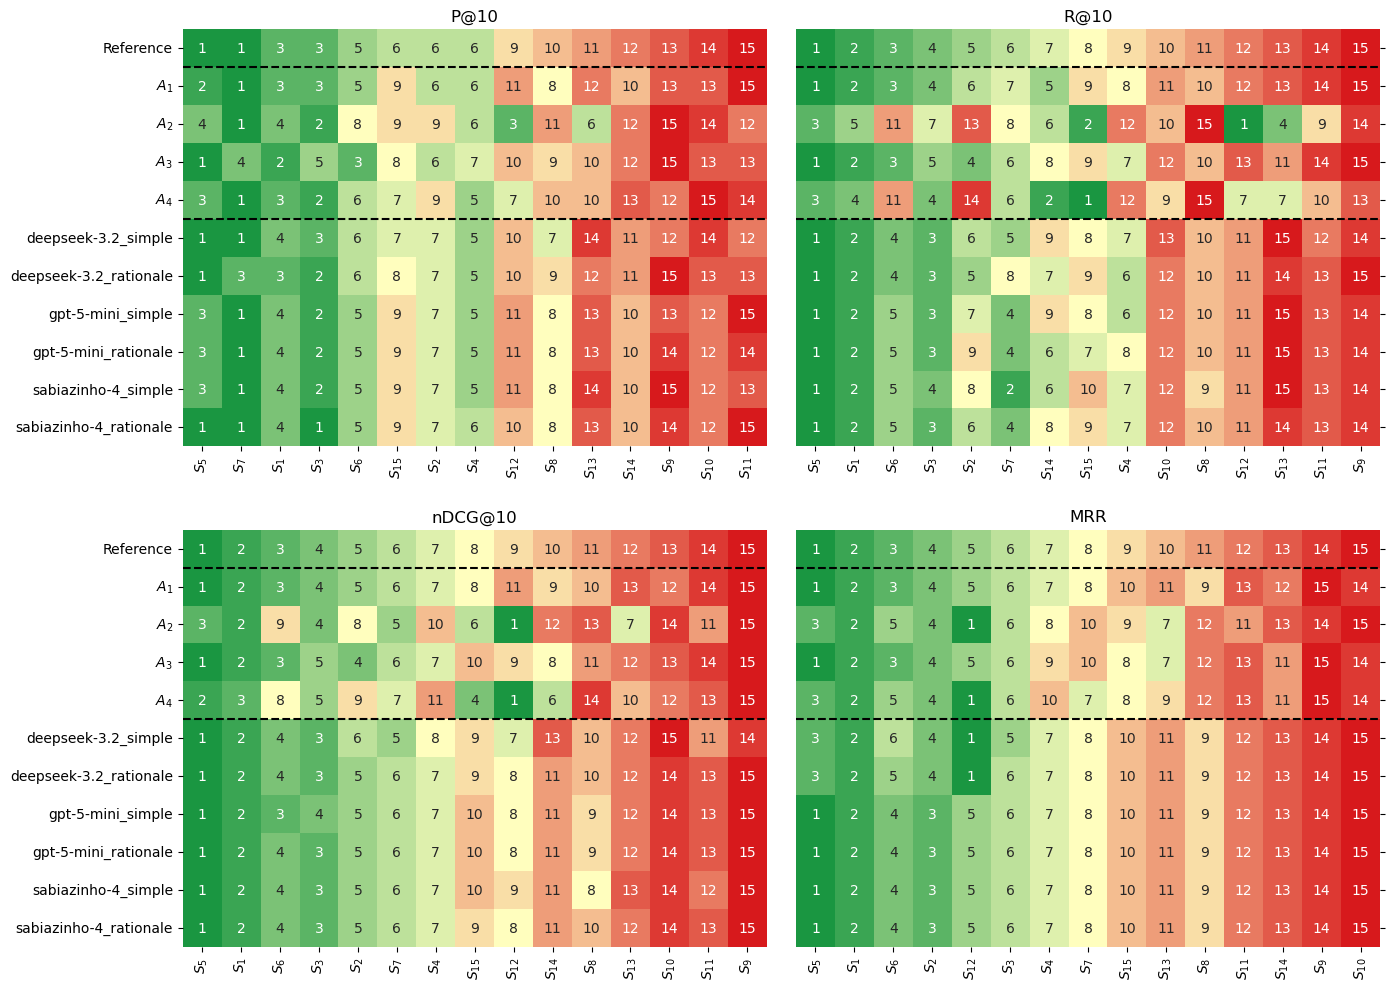

In [15]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

cmap_custom = LinearSegmentedColormap.from_list(
    "rank_cmap",
    ["#1a9641", "#ffffbf", "#d7191c"]
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 🔥 grade 2x2
axes = axes.flatten()  # facilita indexação

for i, metrica in enumerate(metricas_disponiveis):
    ax = axes[i]

    df_metrica = df_metricas[df_metricas["metric"] == metrica]
    pivot = df_metrica.pivot(index="run", columns="qrels", values="value")

    pivot = pivot.sort_values(NOME_QRELS_REF, ascending=False)

    ordered_cols = [c for c in subtitle_order if c in pivot.columns]
    pivot = pivot[ordered_cols]

    rank_df = pivot.rank(ascending=False, method="min").T

    sns.heatmap(
        rank_df,
        annot=True,
        fmt=".0f",
        cmap=cmap_custom,
        cbar=False,   # 🔥 normalmente melhor sem barra em múltiplos plots
        ax=ax         # 🔥 ESSENCIAL
    )

    # eixo X
    runs_fmt = [f"$S_{{{r.split('_')[1]}}}$" for r in rank_df.columns]
    ax.set_xticks(np.arange(len(runs_fmt)) + 0.5)
    ax.set_xticklabels(runs_fmt, rotation=90)

    # eixo Y
    labels_fmt = [
        f"$A_{{{c.split('_')[1]}}}$" if c.startswith("A_") else c
        for c in rank_df.index
    ]
    if i % 2 == 0:
        # 🔥 plots da esquerda → mantem eixo Y
        ax.set_yticks(np.arange(len(labels_fmt)) + 0.5)
        ax.set_yticklabels(labels_fmt, rotation=0)
    else:
        # 🔥 plots da direita → remove eixo Y e coloca na direta os ticks
        ax.set_yticks(np.arange(len(labels_fmt)) + 0.5)
        ax.set_yticklabels([])
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")   


    ax.set_title(metrica)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # 🔥 linhas separadoras
    idx = list(rank_df.index)
    ref_end = next(i for i, x in enumerate(idx) if not x.startswith("Ref"))
    human_end = next(i for i, x in enumerate(idx) if not x.startswith("A_") and not x.startswith("Ref"))
    ax.axhline(ref_end, color='black', linestyle='--', linewidth=1.5)
    ax.axhline(human_end, color='black', linestyle='--', linewidth=1.5)
    # 🔥 linhas internas para LLMs (de 2 em 2)
    #for i in range(human_end + 2, len(idx), 2):
    #    ax.axhline(i, color='gray', linestyle='--', linewidth=1, alpha=0.8)

# 🔥 remove eixos vazios (caso tenha < 4 métricas)
for j in range(len(metricas_disponiveis), 4):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.2)
plt.savefig("heatmap_rankings_llms.png", dpi=600, bbox_inches="tight")
plt.show()

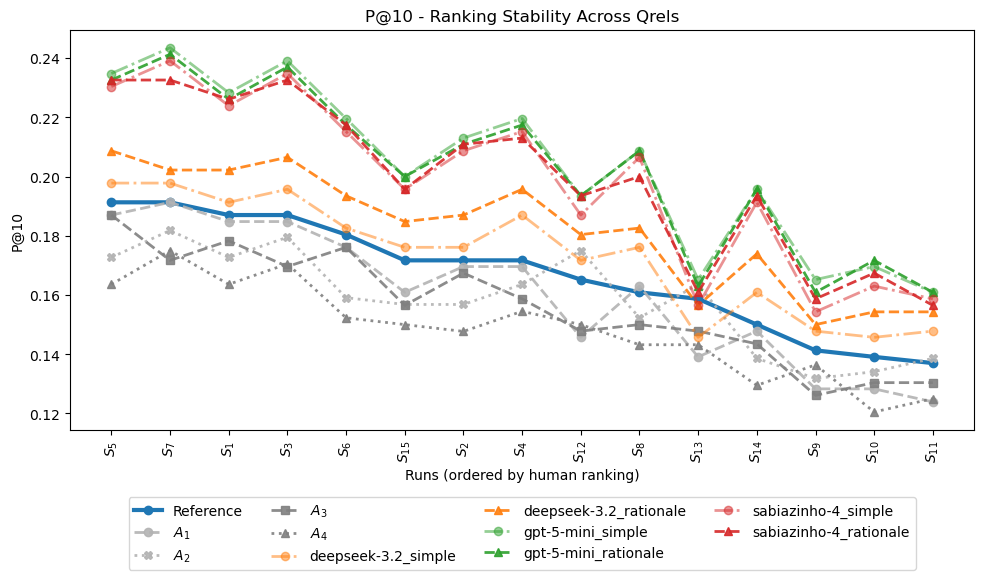

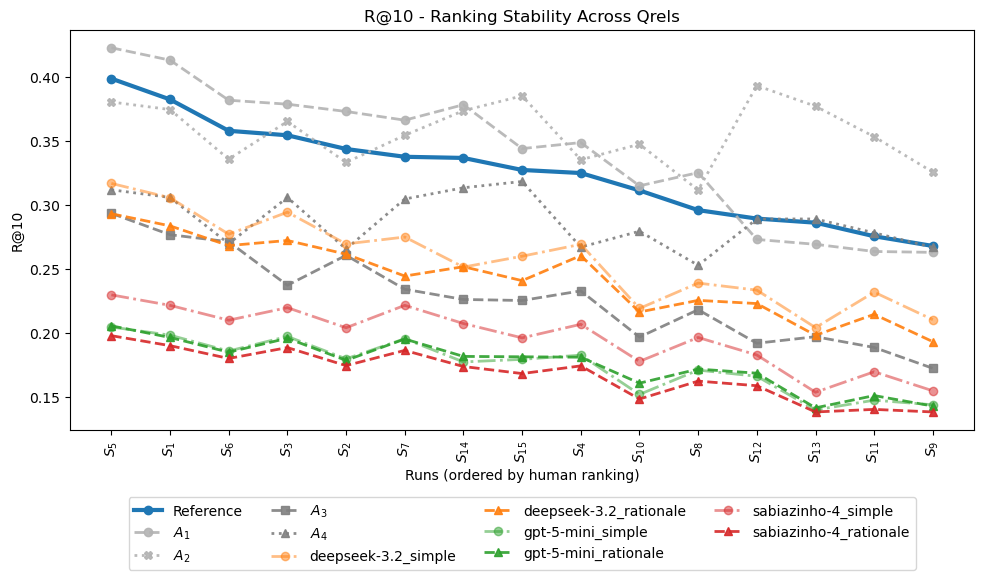

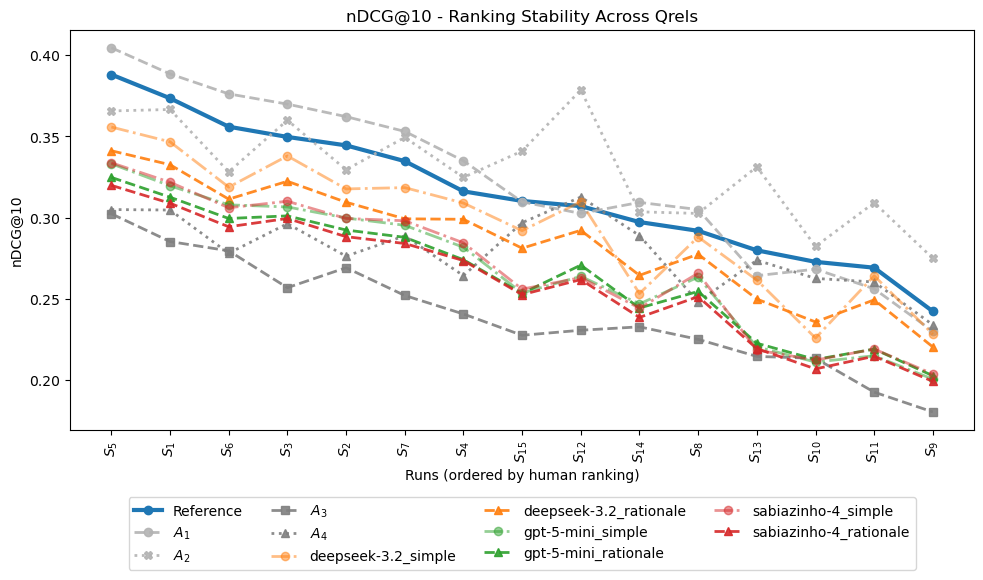

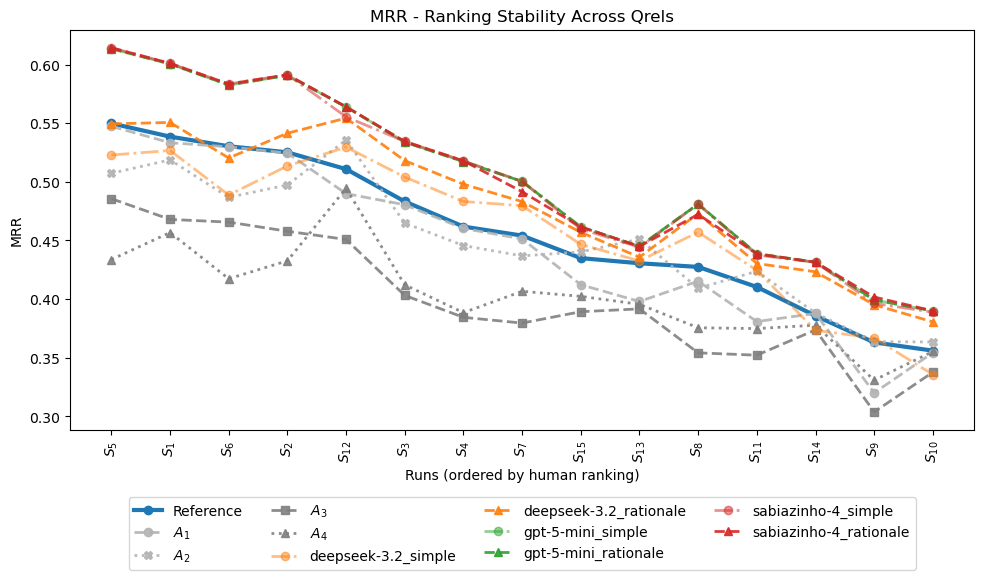

In [16]:
import math
import matplotlib.pyplot as plt

metricas_disponiveis = df_metricas["metric"].unique()

linestyles_nao_continuos = ["--", "-.", ":"]
cores_padrao = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 🔹 Configuração fixa para A_*
config_A = [
    {"marker": "o", "color": "0.7", "linestyle": "--"},  # claro
    {"marker": "X", "color": "0.7", "linestyle": ":"},   # claro
    {"marker": "s", "color": "0.5", "linestyle": "--"},  # escuro
    {"marker": "^", "color": "0.5", "linestyle": ":"},   # escuro
]

for metrica in metricas_disponiveis:
    df_metrica = df_metricas[df_metricas["metric"] == metrica]
    
    pivot = df_metrica.pivot(
        index="run",
        columns="qrels",
        values="value"
    )
       
    pivot = pivot.sort_values(NOME_QRELS_REF, ascending=False)
    
    runs_ordenados = pivot.index.tolist()
    x = range(len(runs_ordenados))
    
    plt.figure(figsize=(10, 6))
    
    lines_dict = {}
    
    # =========================
    # 🔹 Reference (C0 padrão)
    # =========================
    line_ref, = plt.plot(
        x,
        pivot[NOME_QRELS_REF],
        marker="o",
        linestyle="-",
        color="C0",
        linewidth=3,
        label=NOME_QRELS_REF
    )
    lines_dict[NOME_QRELS_REF] = line_ref
    
    # =========================
    # 🔹 Preparação
    # =========================
    modelos = {}
    estilo_por_prompt = {}
    alpha_por_prompt = {}
    
    cor_idx = 1
    idx_A = 0
    
    # =========================
    # 🔹 Plot outros qrels
    # =========================
    for qrels_name in pivot.columns:
        if qrels_name == NOME_QRELS_REF:
            continue
        
        # =====================
        # 🔸 Caso A_*
        # =====================
        if qrels_name.startswith("A_"):
            cfg = config_A[idx_A % len(config_A)]
            idx_A += 1
            
            marker = cfg["marker"]
            color = cfg["color"]
            linestyle = cfg["linestyle"]
            alpha = 0.9
            linewidth = 2
        
        # =====================
        # 🔸 Modelos
        # =====================
        else:
            if "_" in qrels_name:
                modelo, prompt = qrels_name.rsplit("_", 1)
            else:
                modelo, prompt = qrels_name, "default"
            
            # cor por modelo
            if modelo not in modelos:
                modelos[modelo] = f"C{cor_idx % len(cores_padrao)}"
                cor_idx += 1
            
            color = modelos[modelo]
            
            # linestyle por prompt
            if prompt not in estilo_por_prompt:
                estilo_por_prompt[prompt] = linestyles_nao_continuos[
                    len(estilo_por_prompt) % len(linestyles_nao_continuos)
                ]
            
            linestyle = estilo_por_prompt[prompt]
            
            # alpha + marker por prompt
            if prompt not in alpha_por_prompt:
                # alterna entre claro e escuro
                if len(alpha_por_prompt) % 2 == 0:
                    alpha_por_prompt[prompt] = (0.9, "^")  # escuro + triângulo
                else:
                    alpha_por_prompt[prompt] = (0.5, "o")  # claro + bolinha
            
            alpha, marker = alpha_por_prompt[prompt]
            linewidth = 2
        
        line, = plt.plot(
            x,
            pivot[qrels_name],
            marker=marker,
            linestyle=linestyle,
            color=color,
            alpha=alpha,
            linewidth=linewidth,
            label=qrels_name
        )
        
        lines_dict[qrels_name] = line
    
    # =========================
    # 🔹 Ordena legenda
    # =========================
    ordered_handles = [
        lines_dict[name]
        for name in subtitle_order
        if name in lines_dict
    ]
    
    # =========================
    # 🔹 Eixo X
    # =========================
    runs_ordenados_com_subscrito = [
        f"$S_{{{r.split('_')[1]}}}$" if "_" in r else f"${r}$"
        for r in runs_ordenados
    ]
    
    plt.xticks(x, runs_ordenados_com_subscrito, rotation=90)
    plt.xlabel("Runs (ordered by human ranking)")
    plt.ylabel(metrica)
    plt.title(f"{metrica} - Ranking Stability Across Qrels")
    
    # =========================
    # 🔹 Legenda
    # =========================
    plt.legend(
        handles=ordered_handles,
        labels=[f"${x}$" if x.startswith("A_") else x for x in subtitle_order],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=math.ceil(len(ordered_handles)/3)
    )
    
    plt.tight_layout()
    plt.savefig(f"ranking_across_qrels_{metrica.replace('@', '_')}.png", dpi=600, bbox_inches="tight")
    plt.show()

## 6. Bootstrap

Boostrap

In [17]:
from metricas import metricas

results = {}

for qrels_name, df_qrels in qrels.items():
    results.setdefault(qrels_name, {})

    for run_name, df_run in runs.items():
        k=10
        df_resultados = metricas(df_run, df_qrels, k=[k])

        results[qrels_name][run_name] = df_resultados

In [18]:
queries = sorted(
        next(iter(results[qrels_name].values()))
        ["QUERY_KEY"]
        .unique()
    )

In [19]:
from scipy.stats import kendalltau, bootstrap
import numpy as np
import pandas as pd

##############################################################################
# CONFIGURAÇÃO
##############################################################################
QRELS_REFERENCIA = "Reference"

METRICAS = [
    "P@10",
    "R@10",
    "nDCG@10",
    "MRR"
]

##############################################################################
# Método do bootstrap.
#
# Opções do SciPy:
#     "percentile"
#     "basic"
#     "BCa"
##############################################################################
METHOD = "BCa"
N_BOOT = 10000
SEED = 42

rng = np.random.default_rng(SEED)

##############################################################################
# PRÉ-PROCESSAMENTO
##############################################################################
# Converte os dataframes para estruturas NumPy.
#
# Estrutura final:
#
# dados[qrels]["queries"]
#     vetor contendo as queries disponíveis naquele qrels.
#
# dados[qrels][metrica]
#     matriz:
#
#         linhas   -> sistemas
#         colunas  -> queries
#
# Exemplo:
#
# dados["Reference"]["MRR"]
#
# terá shape:
#
#     (15 sistemas, 46 queries)
##############################################################################
print("Preparando estruturas NumPy...")

# Dict principal
dados = {}

for qrels_name in results:
    # Sistemas existentes
    # runs = S_1, S_10, S_11, ...., S_9
    runs = sorted(results[qrels_name])

    # Queries para o qrels
    # Todos os sistemas foram rodadas coma s mesmas queries, então simplesmente pega a do S_1
    queries = sorted(results[qrels_name]['S_1'].QUERY_KEY.unique())

    dados[qrels_name] = {
        "queries": np.array(queries)
    }

    for metrica in METRICAS:
        matriz = []

        # Resultados de cada sistema
        for run_name in runs:
            vetor = (
                results[qrels_name][run_name]
                .set_index("QUERY_KEY")
                .loc[queries][metrica]
                .to_numpy(dtype=np.float32)
            )

            # Adiciona como uma linha na matriz
            matriz.append(vetor)

        ######################################################################
        # Empilha todos os sistemas.
        #
        # Shape final:
        #
        #     (n_sistemas, n_queries)
        ######################################################################
        dados[qrels_name][metrica] = np.vstack(matriz)

##############################################################################
# INTERSEÇÕES
##############################################################################
# Para cada qrels alternativo:
#
#     identifica as queries em comum com a referência.
#
# Também cria os índices necessários para alinhar corretamente
# as colunas das matrizes.
##############################################################################
intersecoes = {}

queries_ref = dados[QRELS_REFERENCIA]["queries"]

##############################################################################
# Mapeia:
#
#     QUERY_KEY -> posição da coluna
##############################################################################
mapa_ref = {
    q: i
    for i, q in enumerate(queries_ref)
}

##############################################################################
# Processa cada qrels alternativo.
##############################################################################
for qrels_name in results:
    ##########################################################################
    # Ignora a própria referência.
    ##########################################################################
    if qrels_name == QRELS_REFERENCIA:
        continue

    ##########################################################################
    # Queries presentes nesse qrels.
    ##########################################################################
    queries_alt = dados[qrels_name]["queries"]

    ##########################################################################
    # QUERY_KEY -> posição.
    ##########################################################################
    mapa_alt = {
        q: i
        for i, q in enumerate(queries_alt)
    }

    ##########################################################################
    # Interseção das queries.
    ##########################################################################
    queries_comuns = sorted(
        set(queries_ref)
        &
        set(queries_alt)
    )

    ##########################################################################
    # Índices das queries comuns na referência.
    ##########################################################################
    idx_ref = np.array(
        [mapa_ref[q] for q in queries_comuns],
        dtype=np.int32
    )

    ##########################################################################
    # Índices das queries comuns no qrels alternativo.
    ##########################################################################
    idx_alt = np.array(
        [mapa_alt[q] for q in queries_comuns],
        dtype=np.int32
    )

    ##########################################################################
    # Armazena informações da interseção.
    ##########################################################################
    intersecoes[qrels_name] = {
        "idx_ref": idx_ref,
        "idx_alt": idx_alt,
        "n_queries": len(queries_comuns)
    }

##############################################################################
# FUNÇÃO AUXILIAR
##############################################################################
# Calcula Kendall τ para:
#
#     - um conjunto de queries
#     - uma métrica
#     - um qrels alternativo
#
# indices_queries:
#     define quais queries serão utilizadas.
#
# No bootstrap, esse vetor contém a reamostragem.
#
# Sem bootstrap:
#
#     [0,1,2,...,45]
#
# Com bootstrap:
#
#     [3,3,8,12,12,12,17,...]
##############################################################################
def calcula_tau_indices(
    indices_queries,
    qrels_name,
    metrica,
    idx_ref,
    idx_alt
):

    ##########################################################################
    # Seleciona as queries desejadas na referência.
    ##########################################################################
    ref = (
        dados[QRELS_REFERENCIA][metrica]
        [:, idx_ref][:, indices_queries]
    )
    ##########################################################################
    # Seleciona as mesmas queries no qrels alternativo.
    ##########################################################################
    alt = (
        dados[qrels_name][metrica]
        [:, idx_alt][:, indices_queries]
    )
    ##########################################################################
    # Média da métrica em todas as queries.
    #
    # Resultado:
    #
    #     um score por sistema
    ##########################################################################
    scores_ref = ref.mean(axis=1)

    scores_alt = alt.mean(axis=1)

    ##########################################################################
    # Calcula Kendall τ-b entre os rankings induzidos pelos scores.
    ##########################################################################
    tau, _ = kendalltau(
        np.round(scores_ref, 4),
        np.round(scores_alt, 4)
    )

    return tau

##############################################################################
# BOOTSTRAP
##############################################################################
# Para cada:
#
#     métrica × qrels
#
# calcula:
#
#     τ observado
#     IC 90%
#     IC 95%
#
# usando o método escolhido.
##############################################################################
linhas = []

##############################################################################
# Processa cada métrica.
##############################################################################
for metrica in METRICAS:
    print(f"\nProcessando {metrica}")
    
    ##########################################################################
    # Processa cada qrels.
    ##########################################################################
    for qrels_name, info in intersecoes.items():

        n_queries = info["n_queries"]

        if n_queries == 0:
            continue

        idx_ref = info["idx_ref"]
        idx_alt = info["idx_alt"]

        ######################################################################
        # τ OBSERVADO
        ######################################################################
        # Usa todas as queries disponíveis.
        ######################################################################
        indices_originais = np.arange(n_queries)

        tau_observed = df_expandido.loc[df_expandido["qrels_comparado"] == qrels_name, f"kendall_tau_{metrica}"].iloc[0]

        ######################################################################
        # Função estatística passada para o bootstrap.
        #
        # O SciPy chamará essa função repetidamente,
        # fornecendo diferentes reamostragens.
        ######################################################################
        def statistic(
            sample,
            axis=None
        ):
            return calcula_tau_indices(
                sample.astype(int),
                qrels_name,
                metrica,
                idx_ref,
                idx_alt
            )

        ######################################################################
        # BCa 90%
        ######################################################################
        res90 = bootstrap(
            data=(indices_originais,),
            statistic=statistic,
            vectorized=False,
            paired=False,
            n_resamples=N_BOOT,
            confidence_level=0.90,
            method=METHOD,
            random_state=rng
        )

        ######################################################################
        # BCa 95%
        ######################################################################
        res95 = bootstrap(
            data=(indices_originais,),
            statistic=statistic,
            vectorized=False,
            paired=False,
            n_resamples=N_BOOT,
            confidence_level=0.95,
            method=METHOD,
            random_state=rng
        )

        ######################################################################
        # Resultados
        ######################################################################
        linhas.append({
            "metric": metrica,
            "qrels": qrels_name,
            "tau_observed": tau_observed,
            "tau_ci_low_90": res90.confidence_interval.low,
            "tau_ci_high_90": res90.confidence_interval.high,
            "tau_ci_low_95": res95.confidence_interval.low,
            "tau_ci_high_95": res95.confidence_interval.high
        })

##############################################################################
# CONSTRÓI DATAFRAME FINAL
##############################################################################

df_taus = pd.DataFrame(linhas)

##############################################################################
# EXIBE RESULTADOS ORDENADOS.
##############################################################################

display(
    df_taus.sort_values(
        ["metric", "tau_observed"],
        ascending=[True, False]
    )
)

Preparando estruturas NumPy...

Processando P@10

Processando R@10

Processando nDCG@10

Processando MRR


,metric,qrels,tau_observed,tau_ci_low_90,tau_ci_high_90,tau_ci_low_95,tau_ci_high_95
32,MRR,gpt-5-mini_rationale,0.94,0.918671,1.000000,0.899532,1.000000
33,MRR,gpt-5-mini_simple,0.94,0.904762,1.000000,0.899532,1.000000
34,MRR,sabiazinho-4_rationale,0.94,0.904762,1.000000,0.894247,1.000000
35,MRR,sabiazinho-4_simple,0.94,0.918671,1.000000,0.885714,1.000000
36,MRR,A_1,0.92,0.847619,1.000000,0.828571,1.000000
30,MRR,deepseek-3.2_rationale,0.85,0.695238,0.956949,0.657143,0.961905
38,MRR,A_3,0.85,0.657143,0.980952,0.580952,0.980952
31,MRR,deepseek-3.2_simple,0.83,0.657143,0.961653,0.580952,0.961905
37,MRR,A_2,0.79,0.542857,0.942857,0.466667,0.961905
39,MRR,A_4,0.77,0.561905,0.961905,0.485714,0.980952


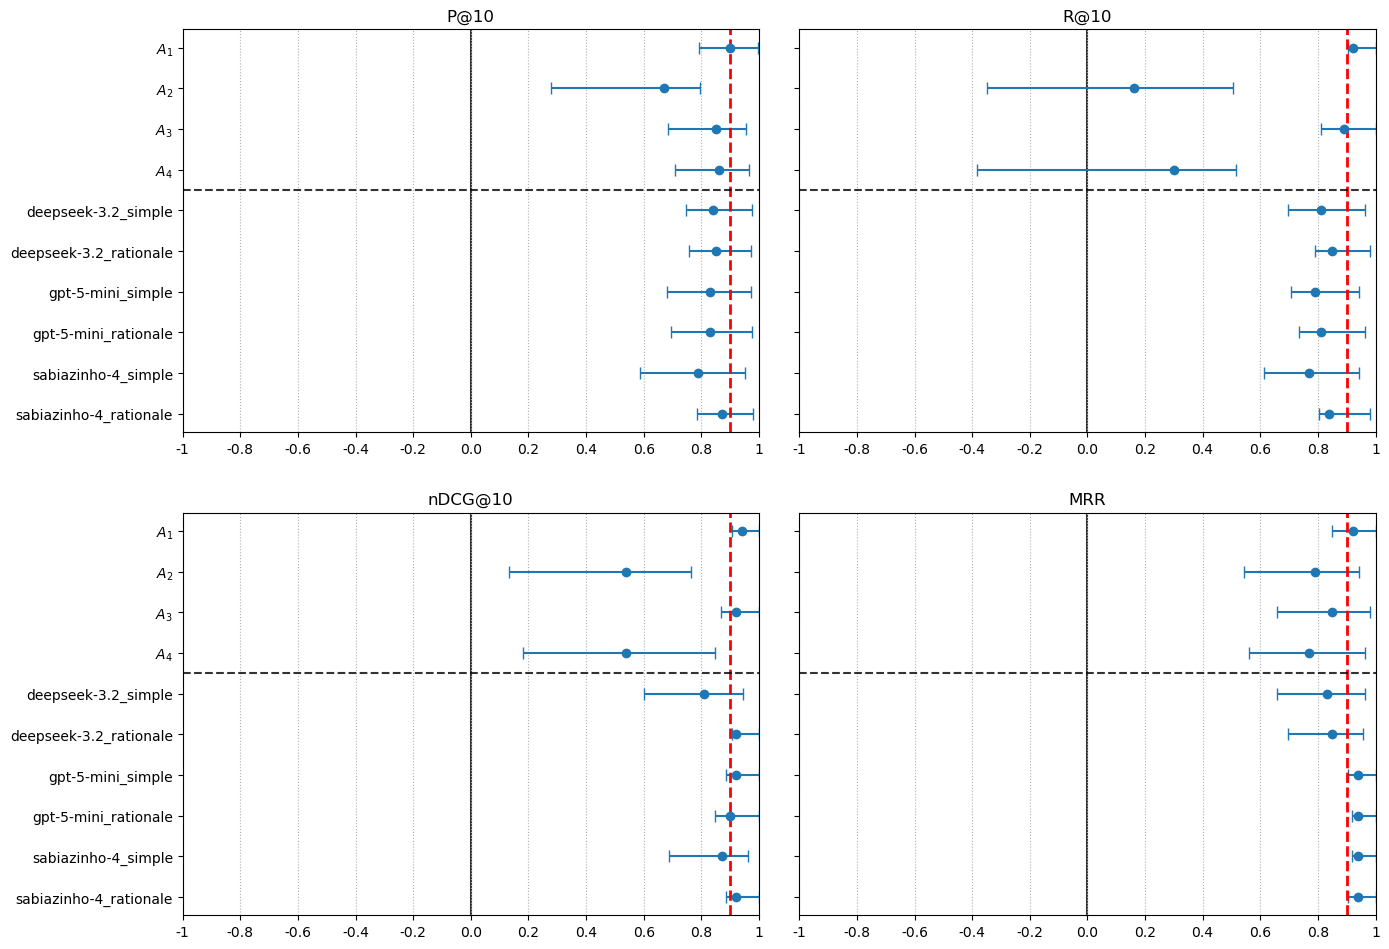

In [26]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from matplotlib.ticker import FuncFormatter

def tick_formatter(x, pos):
    if np.isclose(x, -1):
        return "-1"
    elif np.isclose(x, 1):
        return "1"
    else:
        return f"{x:.1f}"

##############################################################################
# ORDEM
##############################################################################

ordem = [q for q in subtitle_order if q in df_taus["qrels"].unique()]

##############################################################################
# FIGURA 2x2
##############################################################################

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for idx, metrica in enumerate(METRICAS):

    ax = axes[idx]

    ##########################################################################
    # FILTRA MÉTRICA
    ##########################################################################

    df_metric = df_taus[df_taus["metric"] == metrica].copy()

    df_metric["qrels"] = pd.Categorical(
        df_metric["qrels"],
        categories=ordem,
        ordered=True
    )

    df_metric = df_metric.sort_values("qrels")

    ##########################################################################
    # EIXO Y
    ##########################################################################

    y = np.arange(len(df_metric))

    ##########################################################################
    # PONTO OBSERVADO
    ##########################################################################

    x = df_metric["tau_observed"]

    ##########################################################################
    # IC BOOTSTRAP BCa
    ##########################################################################

    xerr = np.vstack([
        x - df_metric["tau_ci_low_90"],
        df_metric["tau_ci_high_90"] - x
    ])

    ax.errorbar(
        x=x,
        y=y,
        xerr=xerr,
        fmt="o",
        capsize=4,
        linewidth=1.5
    )

    ##########################################################################
    # LINHA DE REFERÊNCIA
    ##########################################################################

    ax.axvline(
        0.9,
        linestyle="--",
        linewidth=2,
        color="red"
    )
    
    ax.axvline(
        0,
        color="black",
        linewidth=1.5,
        alpha=0.8,
        zorder=0
    )

    ##########################################################################
    # FORMATAÇÃO
    ##########################################################################

    ax.set_yticks(y)

    ax.xaxis.set_major_locator(MultipleLocator(0.2))
    ax.xaxis.set_major_formatter(FuncFormatter(tick_formatter))

    if idx == 0 or idx == 2:
        ax.set_yticklabels([
            f"${q}$" if q.startswith("A_") else q
            for q in df_metric["qrels"]
        ])
    else:
        ax.set_yticklabels([])
        
    #if idx in [0, 1]:
    #    ax.set_xticklabels([])
        
    ax.axhline(
        y=3.5,
        color="black",
        alpha=0.8,
        linestyle="--",
        linewidth=1.5
    )

    ax.invert_yaxis()

    ax.set_title(metrica)

    ax.grid(
        axis="x",
        linestyle=":"
    )

    ax.set_xlim(-1, 1)

##############################################################################
# FINALIZA
##############################################################################
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.subplots_adjust(wspace=0.07, hspace=0.2)
plt.savefig("figure_7-ic_90_tau.png", dpi=600, bbox_inches="tight")

plt.show()

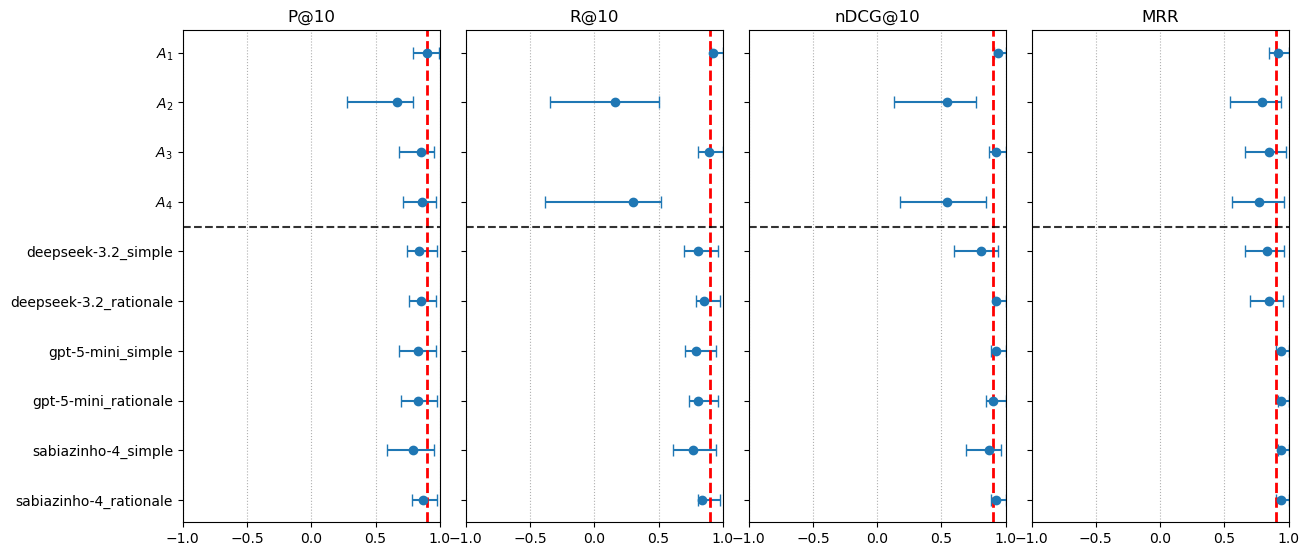

In [21]:
##############################################################################
# ORDEM
##############################################################################

ordem = [q for q in subtitle_order if q in df_taus["qrels"].unique()]

##############################################################################
# FIGURA 2x2
##############################################################################

fig, axes = plt.subplots(1, 4, figsize=(14, 6), sharex=True)

#axes = axes.flatten()

for idx, metrica in enumerate(METRICAS):

    ax = axes[idx]

    ##########################################################################
    # FILTRA MÉTRICA
    ##########################################################################

    df_metric = df_taus[df_taus["metric"] == metrica].copy()

    df_metric["qrels"] = pd.Categorical(
        df_metric["qrels"],
        categories=ordem,
        ordered=True
    )

    df_metric = df_metric.sort_values("qrels")

    ##########################################################################
    # EIXO Y
    ##########################################################################

    y = np.arange(len(df_metric))

    ##########################################################################
    # PONTO OBSERVADO
    ##########################################################################

    x = df_metric["tau_observed"]

    ##########################################################################
    # IC BOOTSTRAP BCa
    ##########################################################################

    xerr = np.vstack([
        x - df_metric["tau_ci_low_90"],
        df_metric["tau_ci_high_90"] - x
    ])

    ax.errorbar(
        x=x,
        y=y,
        xerr=xerr,
        fmt="o",
        capsize=4,
        linewidth=1.5
    )

    ##########################################################################
    # LINHA DE REFERÊNCIA
    ##########################################################################

    ax.axvline(
        0.9,
        linestyle="--",
        linewidth=2,
        color="red"
    )

    ##########################################################################
    # FORMATAÇÃO
    ##########################################################################

    ax.set_yticks(y)

    if idx == 0:
        ax.set_yticklabels([
            f"${q}$" if q.startswith("A_") else q
            for q in df_metric["qrels"]
        ])
    else:
        ax.set_yticklabels([])

    ax.axhline(
        y=3.5,
        color="black",
        alpha=0.8,
        linestyle="--",
        linewidth=1.5
    )
    ax.invert_yaxis()

    ax.set_title(metrica)

    ax.grid(
        axis="x",
        linestyle=":"
    )

    ax.set_xlim(-1, 1)

##############################################################################
# FINALIZA
##############################################################################
plt.subplots_adjust(
    wspace=0.1,
    left=0.20,
    right=0.99,
    bottom=0.10,
    top=0.92
)

plt.savefig("figure_7-ic_90_tau.png", dpi=600, bbox_inches="tight")

plt.show()